In [13]:
import numpy as np
import pandas as pd

# =====================
# Plotting
# =====================
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns

# =====================
# SciPy / Stats
# =====================
from scipy.stats import norm
import statsmodels.api as sm
import statsmodels.formula.api as smf

# =====================
# sklearn – model selection
# =====================
from sklearn.model_selection import train_test_split

# =====================
# sklearn – models
# =====================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =====================
# sklearn – metrics
# =====================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    r2_score,
    mean_squared_error,
)

# =====================
# Utilities
# =====================
from itertools import combinations, product
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import matplotlib as mpl
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm
from matplotlib.patches import Patch



# Some auxiliary functions

In [14]:
# Construct the replicator model
def construct_replicator_features(X):
    linear_part = X.values  # shape: [n_samples, 11]

    # Cross-species interactions only (i < j)
    cross_terms = []
    for i, j in combinations(range(X.shape[1]), 2):
        interaction = - (X.iloc[:, i] * X.iloc[:, j]).values.reshape(-1, 1)
        cross_terms.append(interaction)

    quadratic_part = np.hstack(cross_terms)  # shape: [n_samples, 55]
    features = np.hstack([linear_part, quadratic_part])  # shape: [n_samples, 66]
    return features

# Take the mid point of each Nugent score class. Easier to multiply it by 10 here and divide later
def convert_to_levels(y):
    return pd.cut(
        y,
        bins=[-0.1, 3, 6, 10],  # 3 categories
        labels=[15, 50, 85]     # Midpoints
    ).astype(int)

# Nugent Score transformation
def transform_y(y, N0=None, c=None):
    if N0 is None or c is None:
        return y
    N_max = 10
    d = N_max - 2 * N0 + c
    return np.log(N0 + d) - np.log(N_max - y + c)
import matplotlib.pyplot as plt


#Summarize metrics
def summarize_metrics(metrics_dict, name):
    print(f"\n{name} Average Metrics over {N} runs:")
    for key, values in metrics_dict.items():
        print(f"{key.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Importing the data

In [15]:
data = pd.read_csv("10_species_cleaned_with_ethnicity_and_community.csv")

# Extract response and features
y = data.iloc[:, 3].astype(int)
X_raw = data.iloc[:, 4:]

# Convert to frequencies
X_freq = X_raw[sorted(X_raw.columns)]
X_freq = X_freq.iloc[:, 1:] #Remove unassigned
X_freq = X_freq.div(X_freq.sum(axis=1), axis=0)

# Figure 2

In [16]:
def fit_transformed_ridge_on_full_data(X, y, N0=None, c=None, alpha=1.0, n_boot=1000, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    # Transform y
    y_transformed = transform_y(y / 10, N0, c)

    # Replicator features
    X_rep = construct_replicator_features(X)

    # Build feature names
    base_names = [
    'Actinomycetota',
    'Bacillota_A_368345',
    'Bacillota_C',
    'Bacillota_I',
    'Bacteroidota',
    'Campylobacterota_A',
    'Fusobacteriota',
    'Patescibacteria',
    'Pseudomonadota',
    'Synergistota'
]
    if X.shape[1] > len(base_names):
        base_names += [f"x{i}" for i in range(len(base_names), X.shape[1])]

    interaction_names = [
        f"{base_names[i]} * {base_names[j]}"
        for i, j in combinations(range(X.shape[1]), 2)
    ]
    feature_names = base_names + interaction_names

    # Fit Ridge regression
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X_rep, y_transformed)
    r2 = model.score(X_rep, y_transformed)

    # Collect coefficients
    model_params_df = pd.DataFrame([model.coef_], columns=feature_names)


    return model_params_df, model, r2

def fit_transformed_ridge_on_full_data(
    X, y, N0=None, c=None, alpha=1.0, n_boot=1000, random_state=None
):
    if random_state is not None:
        np.random.seed(random_state)

    # Ensure arrays for internal use (but keep original types for nicer indexing if you want)
    X_is_df = isinstance(X, pd.DataFrame)
    y_is_series = isinstance(y, pd.Series)

    # Transform y
    y_transformed = transform_y((y / 10), N0, c)

    # Replicator features (apply to full X)
    X_rep = construct_replicator_features(X)

    # Build feature names
    base_names = [
    'Actinomycetota',
    'Bacillota_A_368345',
    'Bacillota_C',
    'Bacillota_I',
    'Bacteroidota',
    'Campylobacterota_A',
    'Fusobacteriota',
    'Patescibacteria',
    'Pseudomonadota',
    'Synergistota'
    ]
    if X.shape[1] > len(base_names):
        base_names += [f"x{i}" for i in range(len(base_names), X.shape[1])]

    interaction_names = [
        f"{base_names[i]} * {base_names[j]}"
        for i, j in combinations(range(X.shape[1]), 2)
    ]
    feature_names = base_names + interaction_names

    # Fit Ridge on full data
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X_rep, y_transformed)
    r2 = model.score(X_rep, y_transformed)
    coef_full = model.coef_.copy()

    # Prepare bootstrap storage
    n_samples = X.shape[0]
    p = len(feature_names)
    boot_coefs = np.zeros((n_boot, p))

    # Bootstrap loop (use .iloc for DataFrame row sampling)
    for b in range(n_boot):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        Xb = X.iloc[idx] if X_is_df else X[idx]
        yb = y.iloc[idx] if y_is_series else y[idx]

        yb_transformed = transform_y((yb / 10), N0, c)
        Xb_rep = construct_replicator_features(Xb)

        boot_model = Ridge(alpha=alpha, fit_intercept=False)
        boot_model.fit(Xb_rep, yb_transformed)
        boot_coefs[b, :] = boot_model.coef_

    # Bootstrap summaries
    boot_mean = np.mean(boot_coefs, axis=0)
    boot_std = np.std(boot_coefs, axis=0, ddof=1)

    # 95% percentile confidence intervals
    ci_lower = np.percentile(boot_coefs, 2.5, axis=0)
    ci_upper = np.percentile(boot_coefs, 97.5, axis=0)


    # Assemble results DataFrame
    results_df = pd.DataFrame({
        "coef": coef_full,
        "boot_mean": boot_mean,
        "boot_std": boot_std,
        "ci_lower_95": ci_lower,
        "ci_upper_95": ci_upper
    }, index=feature_names)

    return results_df, model, r2

In [17]:
y_levels = convert_to_levels(y)

N0 = 4.5
c=4

results_df, model, r2 = fit_transformed_ridge_on_full_data(
    X_freq, y_levels, N0=N0, c=c, alpha = 0.05
)

[Text(0.5, 0, 'Actinomycetota'),
 Text(1.5, 0, 'Bacillota_A_368345'),
 Text(2.5, 0, 'Bacillota_C'),
 Text(3.5, 0, 'Bacillota_I'),
 Text(4.5, 0, 'Bacteroidota'),
 Text(5.5, 0, 'Campylobacterota_A'),
 Text(6.5, 0, 'Fusobacteriota'),
 Text(7.5, 0, 'Patescibacteria'),
 Text(8.5, 0, 'Pseudomonadota'),
 Text(9.5, 0, 'Synergistota')]

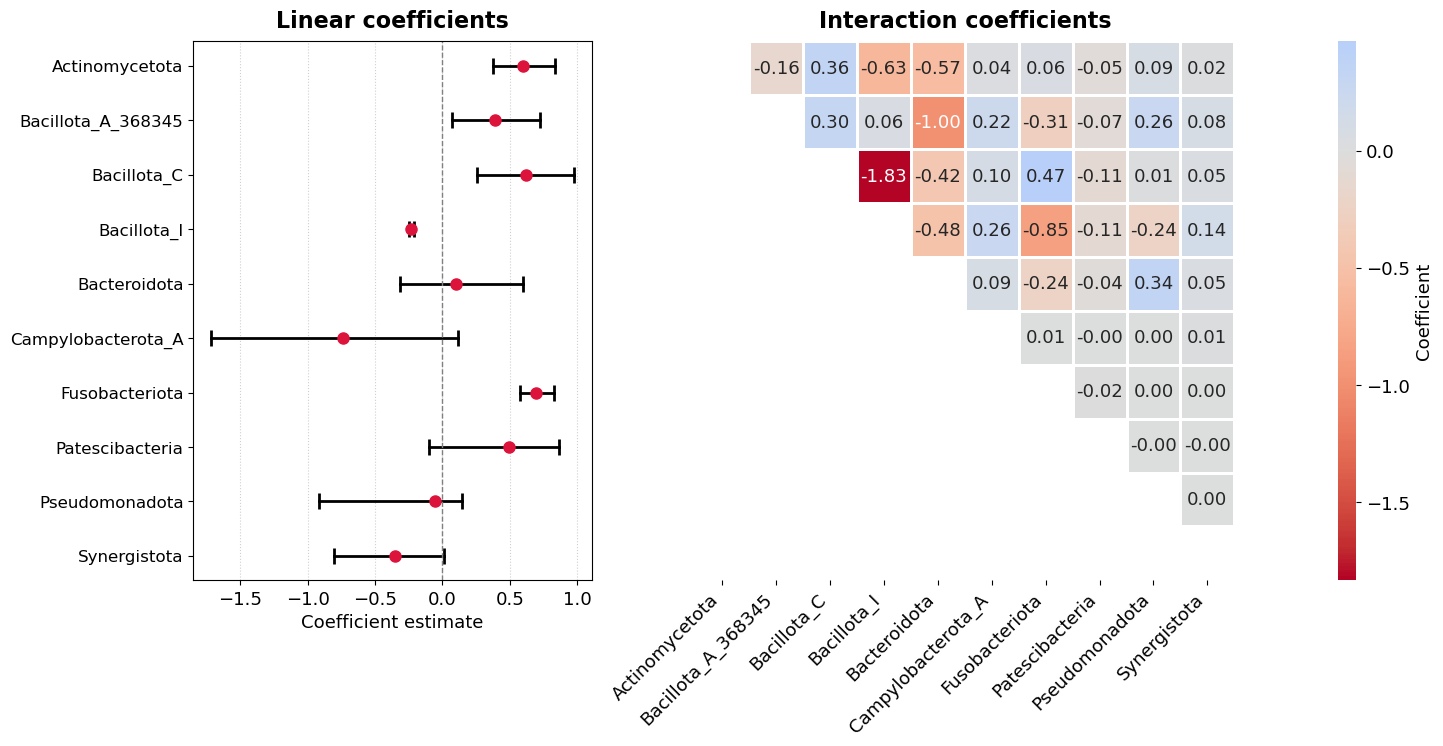

In [29]:
def plot_coefficients_ridge_ax(
    ax,
    coefs,
    ci_lower,
    ci_upper,
    feature_names,
    title=None,
):
    coefs = np.asarray(coefs)
    ci_lower = np.asarray(ci_lower)
    ci_upper = np.asarray(ci_upper)

    n = len(feature_names)

    # Reverse order so Actinomycetota is on top
    y_positions = np.arange(n)[::-1]

    for y, coef, lower, upper in zip(
        y_positions, coefs, ci_lower, ci_upper
    ):
        ax.plot([lower, upper], [y, y], color="black", lw=2)
        ax.plot(lower, y, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(upper, y, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(coef, y, "o", color="crimson", markersize=8)

    ax.axvline(0, color="gray", linestyle="--", lw=1)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(feature_names, fontsize=12)
    ax.set_xlabel("Coefficient estimate")

    if title is not None:
        ax.set_title(title, fontweight="bold", pad=10)

    ax.grid(axis="x", linestyle=":", alpha=0.6)

def plot_interaction_heatmaps_single_fit_ax(
    results_df,
    custom_labels,
    ax,
    cbar_ax=None,
):
    n_vars = len(custom_labels)

    interaction_df = results_df.iloc[n_vars:]
    interaction_coefs = interaction_df["coef"].values

    coef_matrix = np.full((n_vars, n_vars), np.nan)

    for k, (i, j) in enumerate(combinations(range(n_vars), 2)):
        if k < len(interaction_coefs):
            coef_matrix[i, j] = interaction_coefs[k]

    mask = np.tril(np.ones_like(coef_matrix, dtype=bool), k=0)

    sns.heatmap(
        coef_matrix,
        mask=mask,
        cmap="coolwarm_r",
        center=0,
        xticklabels=custom_labels,
        yticklabels=custom_labels,
        annot=True,
        fmt=".2f",
        linewidths=0.8,
        square=True,
        ax=ax,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={"label": "Coefficient"},
    )

    ax.set_title(
        "Interaction coefficients",
        fontweight="bold",
        pad=10
    )


# --- Figure layout ---
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1.1, 1.6, 0.05],
    wspace=0.25
)

ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])
cax      = fig.add_subplot(gs[0, 2])

linear_feature_names = [
    "Actinomycetota",
    "Bacillota_A_368345",
    "Bacillota_C",
    "Bacillota_I",
    "Bacteroidota",
    "Campylobacterota_A",
    "Fusobacteriota",
    "Patescibacteria",
    "Pseudomonadota",
    "Synergistota",
]

plot_coefficients_ridge_ax(
    ax_left,
    results_df.iloc[0:10, 1],  # boot_mean
    results_df.iloc[0:10, 3],  # ci_lower_95
    results_df.iloc[0:10, 4],  # ci_upper_95
    linear_feature_names,
    title="Linear coefficients",
)

# ax_left.text(
#     -0.18, 1.05, "A",
#     transform=ax_left.transAxes,
#     fontsize=20,
#     fontweight="bold",
#     va="top"
# )
plot_interaction_heatmaps_single_fit_ax(
    results_df,
    linear_feature_names,
    ax=ax_right,
    cbar_ax=cax,
)

# Remove redundant y-axis labels
ax_right.set_yticklabels([])
ax_right.set_ylabel("")
ax_right.tick_params(axis="y", length=0)

# Improve x-label readability
ax_right.set_xticklabels(
    ax_right.get_xticklabels(),
    rotation=45,
    ha="right"
)

# fig.savefig(
#     "ridge_linear_and_interactions.pdf",
#     dpi=1000,
#     bbox_inches="tight"
# )


# Figures S4 and S5

In [30]:
# Auxiliary functions
def plot_quadratic_coefficients_ridge_like_linear(linear_params_df, ci_lower_df, ci_upper_df, feature_names):
    # Convert to numpy arrays (in case they're pandas Series)
    coefs = np.asarray(linear_params_df)
    ci_lower = np.asarray(ci_lower_df)
    ci_upper = np.asarray(ci_upper_df)
    
    fig, ax = plt.subplots(figsize=(10, 14))

    # Plot each coefficient with its confidence interval
    for i, (coef, lower, upper) in enumerate(zip(coefs, ci_lower, ci_upper)):
        ax.plot([lower, upper], [i, i], color="black", lw=2)
        ax.plot(lower, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(upper, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(coef, i, "o", color="crimson", markersize=8)

    # Formatting
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=14)
    ax.set_xlabel("Coefficient estimate", fontsize=16)

    
    ax.set_title("95% Bootstrap confidence intervals for the interaction coefficients", fontsize=16, pad=15, fontweight="bold")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    fig.tight_layout()
    
    return fig

def plot_quadratic_coefficients_ridge_like_linear_filtered(
    linear_params_df, ci_lower_df, ci_upper_df, feature_names
):
    import numpy as np
    import matplotlib.pyplot as plt

    # Convert to numpy arrays
    coefs = np.asarray(linear_params_df)
    ci_lower = np.asarray(ci_lower_df)
    ci_upper = np.asarray(ci_upper_df)
    feature_names = np.asarray(feature_names)

    # --- FILTER: keep only CIs that do NOT contain 0 ---
    mask = (ci_lower > 0) | (ci_upper < 0)

    coefs = coefs[mask]
    ci_lower = ci_lower[mask]
    ci_upper = ci_upper[mask]
    feature_names = feature_names[mask]

    fig, ax = plt.subplots(figsize=(10, 0.6 * len(coefs) + 2))

    # Plot each coefficient with its confidence interval
    for i, (coef, lower, upper) in enumerate(zip(coefs, ci_lower, ci_upper)):
        ax.plot([lower, upper], [i, i], color="black", lw=2)
        ax.plot(lower, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(upper, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(coef, i, "o", color="crimson", markersize=8)

    # Formatting
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=14)
    ax.set_xlabel("Coefficient estimate", fontsize=16)

    ax.set_title(
        "95% Bootstrap confidence intervals (excluding CIs containing 0)",
        fontsize=16,
        pad=15,
        fontweight="bold",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.6)
    fig.tight_layout()

    return fig

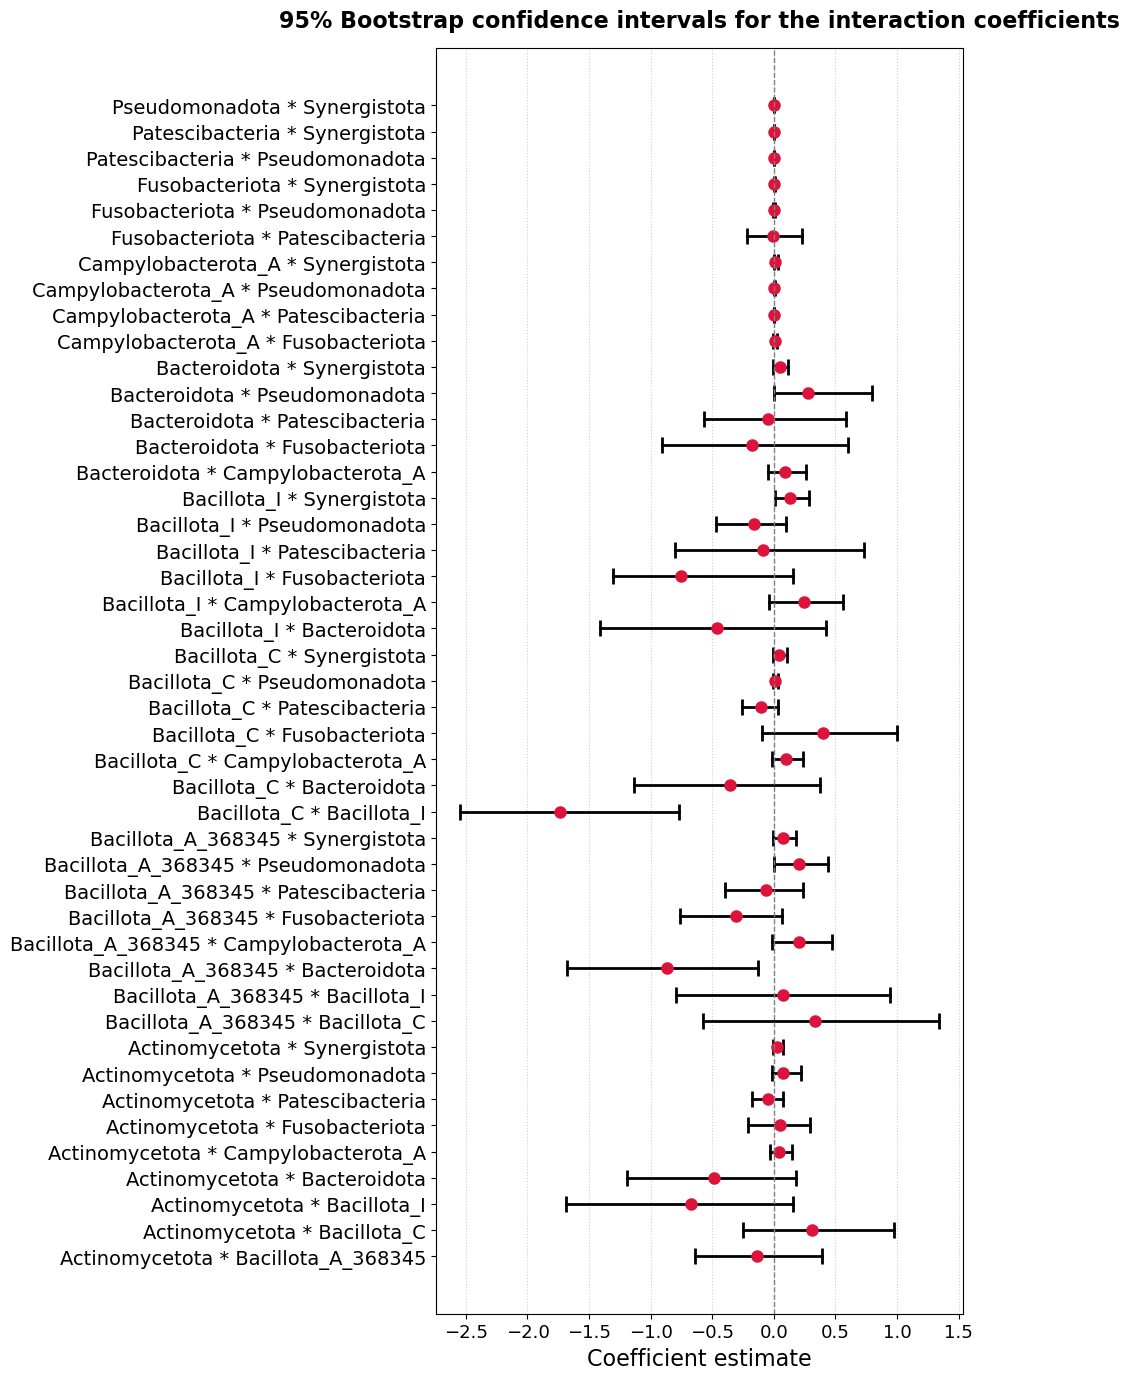

In [31]:
linear_params_df = results_df.iloc[10:, 1]   # boot_mean column
ci_lower_df = results_df.iloc[10:, 3]        # ci_lower_95 column
ci_upper_df = results_df.iloc[10:, 4]        # ci_upper_95 column

interaction_names = [
    f"{linear_feature_names[i]} * {linear_feature_names[j]}"
    for i, j in combinations(range(10), 2)
]

fig = plot_quadratic_coefficients_ridge_like_linear(linear_params_df, ci_lower_df, ci_upper_df, interaction_names)

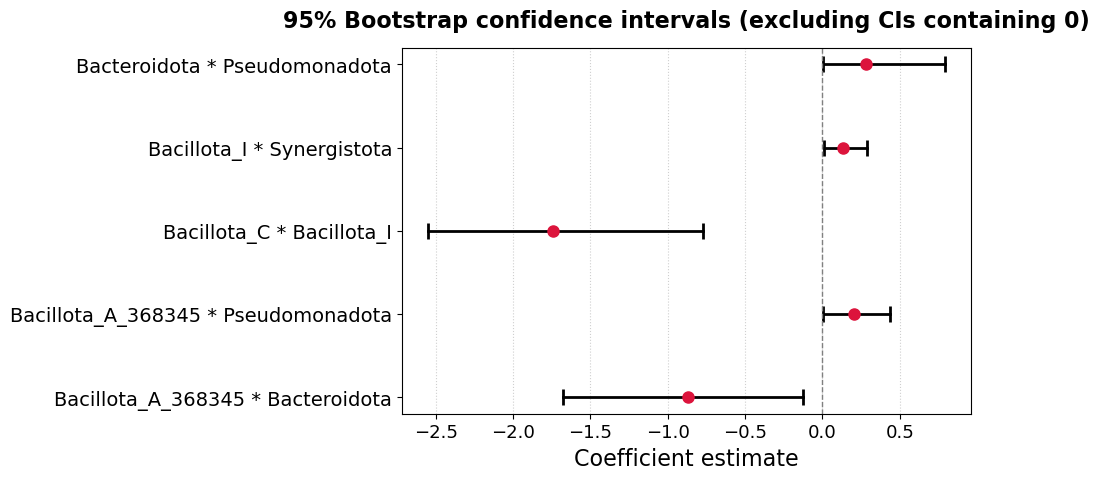

In [32]:
fig = plot_quadratic_coefficients_ridge_like_linear_filtered(linear_params_df, ci_lower_df, ci_upper_df, interaction_names)


# Figure 3

In [37]:
# Some needed functions:

def compute_full_interaction_term(X, model):
    """
    Computes the full interaction contribution:
      sum_{i<j} beta_ij * (x_i x_j )
    
    Returns: vector of shape (n_samples,)
    """

    p = X.shape[1]
    coef = model.coef_

    # split coefficients
    beta_Q = coef[p:]   # interaction coefficients only

    # build interaction features
    cross_terms = []
    for i, j in combinations(range(p), 2):
        interaction =  (X.iloc[:, i] * X.iloc[:, j]).values.reshape(-1, 1)
        cross_terms.append(interaction)

    Q = np.hstack(cross_terms)   # [n_samples, n_interactions]

    # full interaction contribution
    interaction_part = Q @ beta_Q   # shape: (n_samples,)

    return interaction_part

def predict_from_row_raw(model, X_row):

    # Build replicator features
    X_rep = construct_replicator_features(X_row)

    # Predict transformed value
    y_pred_transformed = model.predict(X_rep)
    return y_pred_transformed

def predict_from_row_transformed(model, X_row, N0=4.5, c=4):

    # Build replicator features
    X_rep = construct_replicator_features(X_row)

    # Predict transformed value
    y_pred_transformed = model.predict(X_rep)

    # Convert transformed prediction back to N
    N_pred = 10 + c - (10 - N0 + c) / np.exp(y_pred_transformed)

    # Find closest level (using your scale)
    closest_label = min([15, 50, 85], key=lambda x: abs(x - 10 * N_pred))

    # Convert to category
    if closest_label == 15:
        return "0-3"
    elif closest_label == 50:
        return "4-6"
    else:  # 85
        return "7-10"

In [36]:
interaction_term = compute_full_interaction_term(X_freq, model)

In [38]:
df = X_freq.copy()
df["interaction"] = interaction_term
df["Community_group"] = data['Community groupc ']  # adjust to your actual df
df["Nugent"] = data['Nugent score']
df["Nugent_group"] = np.digitize(df["Nugent"], [0, 3, 6, 10], right=True)

group_map = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5}
df["group_num"] = df["Community_group"].map(group_map)

df = df.sort_values(
    ["group_num", "Nugent_group", "interaction"],
    ascending=[True, True, False]
).reset_index(drop=True)

In [39]:
predictions = []
X_sorted = df[X_freq.columns]

for i in range(len(X_freq)):
    pred = predict_from_row_raw(model, X_sorted.iloc[[i]])  # one row at a time
    predictions.append(pred[0])

predictions_transformed = []
X_sorted = df[X_freq.columns]

for i in range(len(X_freq)):
    pred = predict_from_row_transformed(model, X_sorted.iloc[[i]])  # one row at a time
    predictions_transformed.append(pred[0])

/var/folders/0g/6n85dcys0s9gtyx9gpd854pw0000gn/T/ipykernel_7282/613686581.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(


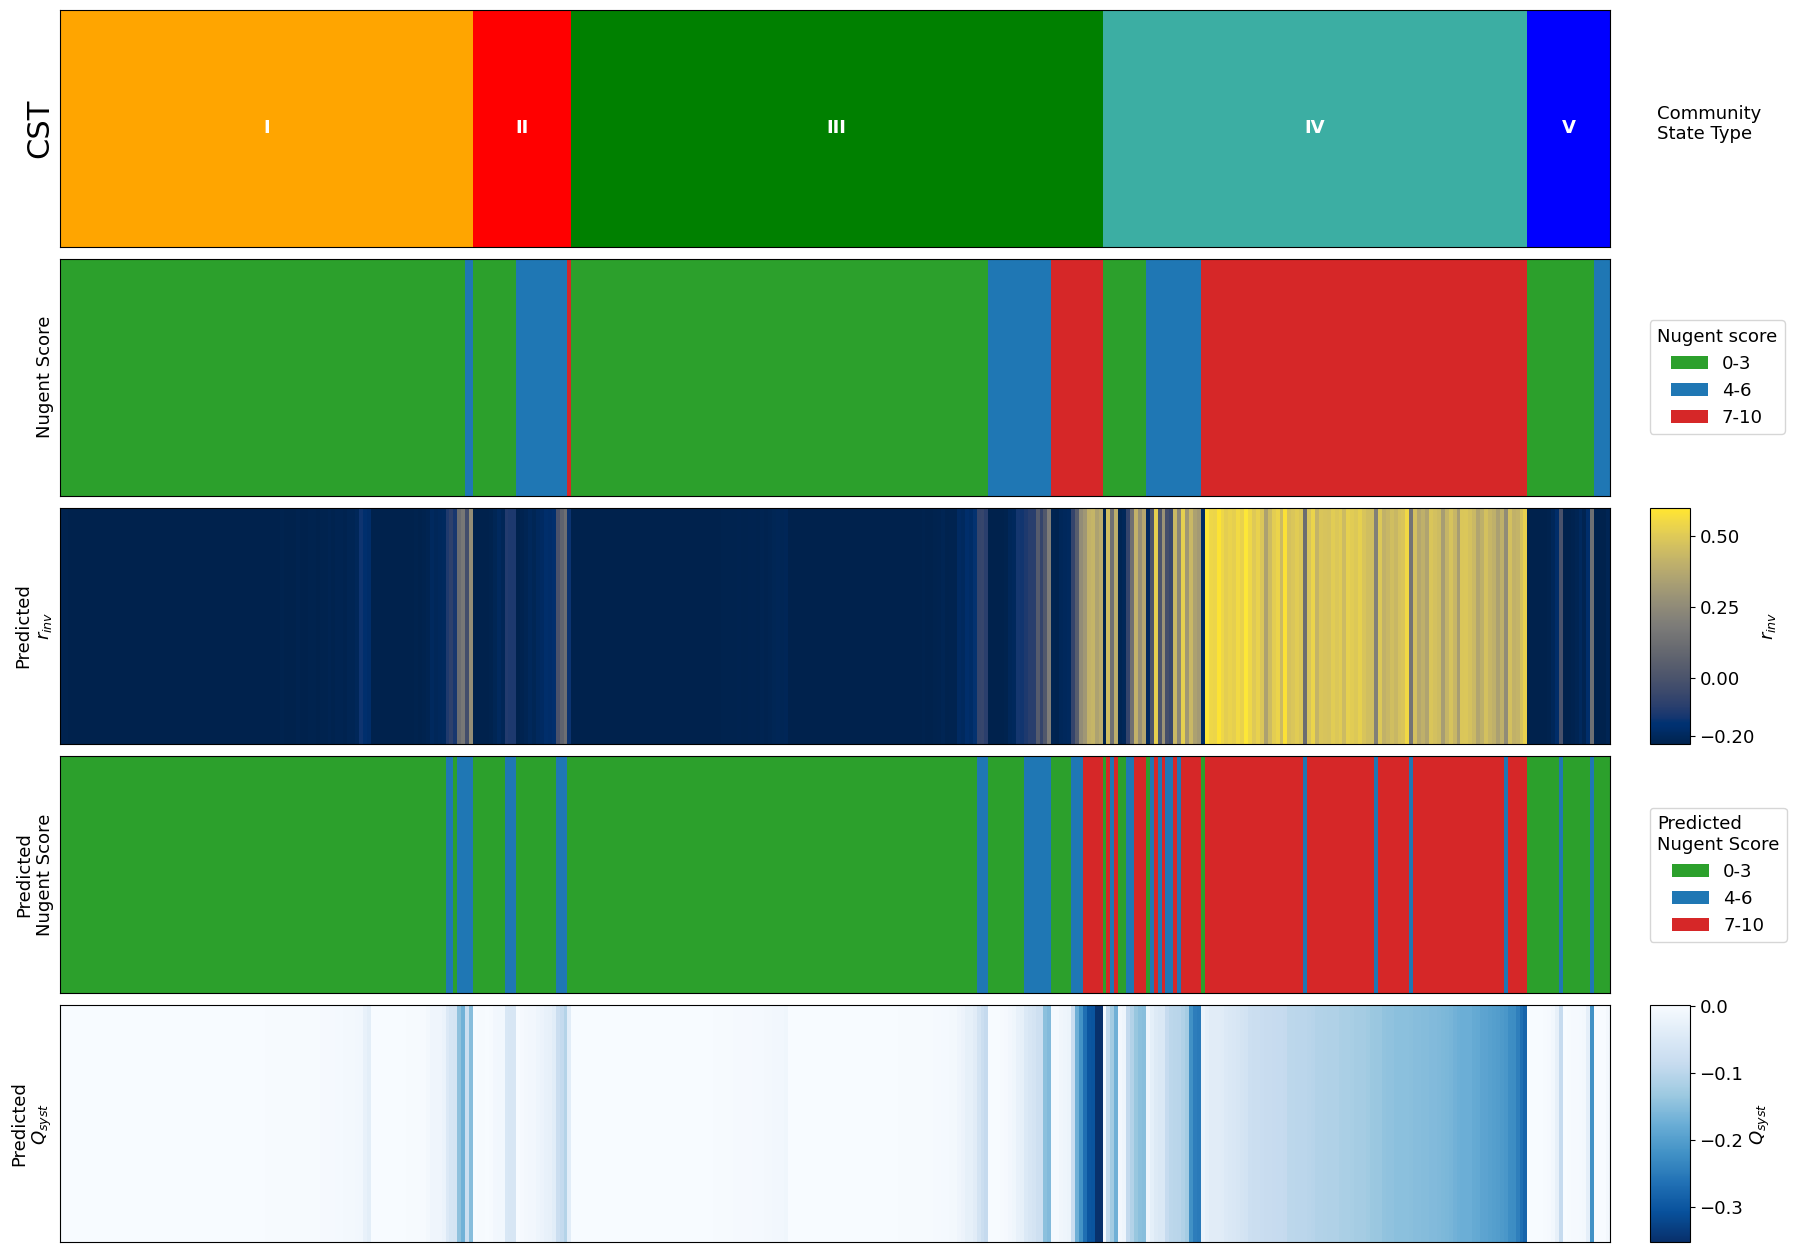

In [42]:
def plot_community_nugent_interaction_with_predictions_both(df, predictions, predictions_transformed, filename=None):
    x = np.arange(len(df))
    
    interaction = df["interaction"].values
    group_num = df["group_num"].values
    nugent = df["Nugent"].values
    predictions = np.array(predictions)
    predictions_transformed = np.array(predictions_transformed)
    
    # --- Create figure and axes ---
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
        5, 1, figsize=(20, 16),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1, 1, 1], "hspace": 0.05}
    )
    
    # --- Community group ---
    cmap_groups = ListedColormap(["orange", "red", "green", "#3caea3", "blue"])
    bounds = [0.5,1.5,2.5,3.5,4.5,5.5]
    norm_groups = BoundaryNorm(bounds, cmap_groups.N)
    ax1.imshow(group_num.reshape(1, -1), aspect="auto",
               cmap=cmap_groups, norm=norm_groups)
    ax1.set_yticks([])
    ax1.set_ylabel("CST", fontsize=22)
    for i in range(1,6):
        mask = group_num == i
        if mask.any():
            center = np.where(mask)[0].mean()
            ax1.text(center, 0, ["I","II","III","IV","V"][i-1],
                     ha="center", va="center", color="white",  fontweight="bold")
    legend_elements = [Patch(facecolor=cmap_groups(i), label=l)
                       for i,l in zip(range(5), ["I","II","III","IV","V"])]
    #ax1.legend(handles=legend_elements, title="Community group",
     #          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=22)

    
    ax1.legend(
        title="Community\nState Type",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # --- Nugent score groups ---
    nugent_bins = [0, 3, 6, 10]
    nugent_colors = ["#2ca02c", "#1f77b4", "#d62728"]  # Green, Blue, Red
    nugent_digitized = np.digitize(nugent, nugent_bins, right=True) - 1
    cmap_nugent = ListedColormap(nugent_colors)
    norm_nugent = BoundaryNorm([0,1,2,3], cmap_nugent.N)
    
    ax2.imshow(nugent_digitized.reshape(1, -1), aspect="auto",
               cmap=cmap_nugent, norm=norm_nugent)
    ax2.set_yticks([])
    ax2.set_ylabel("Nugent Score")
    legend_nugent = [Patch(facecolor=color, label=label)
                     for color, label in zip(nugent_colors, ["0-3", "4-6", "7-10"])]
    ax2.legend(handles=legend_nugent, title="Nugent score",
               loc="center left", bbox_to_anchor=(1.02, 0.5))


    
    im3 = ax3.imshow(predictions.reshape(1, -1), aspect="auto", cmap="cividis")
    ax3.set_yticks([])
    ax3.set_ylabel("Predicted\n$r_{inv}$")
    
    cbar_ax3 = fig.add_axes([0.92, ax3.get_position().y0, 0.02, ax3.get_position().height])
    cbar3 = fig.colorbar(im3, cax=cbar_ax3)
    cbar3.set_ticks([-0.2, 0 , 0.25, 0.5])
    cbar3.set_label("$r_{inv}$")
    
    # --- Transformed Predictions (binned like Nugent) ---
    pred_trans_digitized = np.digitize(predictions_transformed, nugent_bins, right=True) - 1
    im4 = ax4.imshow(pred_trans_digitized.reshape(1, -1),
                     aspect="auto",
                     cmap=cmap_nugent, norm=norm_nugent,
                    alpha=1)
    ax4.set_yticks([])
    ax4.set_ylabel("Predicted\nNugent Score")
    legend_pred_trans = [Patch(facecolor=color, label=label)
                         for color, label in zip(nugent_colors, ["0-3", "4-6", "7-10"])]
    ax4.legend(handles=legend_pred_trans, title="Predicted\nNugent Score",
               loc="center left", bbox_to_anchor=(1.02, 0.5))

    
    # --- Interaction ---
    im5 = ax5.imshow(interaction.reshape(1, -1), aspect="auto", cmap="Blues_r")
    ax5.set_yticks([])
    ax5.set_ylabel("Predicted\n$Q_{syst}$")

    # Create separate axes on the right for the vertical colorbar
    cbar_ax5 = fig.add_axes([0.92, ax5.get_position().y0, 0.02, ax5.get_position().height])
    cbar5 = fig.colorbar(im5, cax=cbar_ax5)
    cbar5.set_label("$Q_{syst}$")
    
    #ax1.set_title("Community – Nugent – Interaction – Prediction – Prediction Transformed")

    


    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.set_xticks([])  # removes tick marks
        ax.set_xticklabels([])  # removes any labels

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight')  
        print(f"Figure saved to {filename}")

    plt.show()

plot_community_nugent_interaction_with_predictions_both(df, predictions, predictions_transformed)

# Figure S2

In [43]:
def plot_species_with_cst_nugent_log(
    X_freq, df,
    species_names=None,
    filename=None,
    eps=1e-6
):
    """
    X_freq: DataFrame (n_samples, 10 species), values in [0,1]
    df: original dataframe containing 'group_num' (CST) and 'Nugent'
    """

    # =========================
    # Data
    # =========================
    freq_matrix = X_freq.values.T
    freq_matrix_safe = freq_matrix + eps

    group_num = df["group_num"].values
    nugent = df["Nugent"].values

    n_species, n_samples = freq_matrix.shape
    total_rows = 2 + n_species  # CST + Nugent + species

    # =========================
    # Figure
    # =========================
    fig, ax = plt.subplots(figsize=(22, 16))

    # =========================
    # Colormaps
    # =========================
    cmap_groups = ListedColormap(["orange", "red", "green", "#3caea3", "blue"])
    bounds = [0.5,1.5,2.5,3.5,4.5,5.5]
    norm_groups = BoundaryNorm(bounds, cmap_groups.N)

    nugent_bins = [0, 3, 6, 10]
    nugent_colors = ["#2ca02c", "#1f77b4", "#d62728"]
    cmap_nugent = ListedColormap(nugent_colors)
    norm_nugent = BoundaryNorm([0,1,2,3], cmap_nugent.N)
    nugent_digitized = np.digitize(nugent, nugent_bins, right=True) - 1

    # =========================
    # Plot rows
    # =========================
    # CST row (bottom)
    ax.imshow(
        group_num.reshape(1, -1),
        aspect="auto",
        cmap=cmap_groups,
        norm=norm_groups,
        extent=[0, n_samples, 0, 1]
    )

    # Nugent row
    ax.imshow(
        nugent_digitized.reshape(1, -1),
        aspect="auto",
        cmap=cmap_nugent,
        norm=norm_nugent,
        extent=[0, n_samples, 1, 2]
    )

    # Species rows
    im = ax.imshow(
        freq_matrix_safe,
        aspect="auto",
        cmap="viridis",
        norm=LogNorm(vmin=eps, vmax=1),
        extent=[0, n_samples, 2, 2 + n_species]
    )

    # =========================
    # Labels
    # =========================
    if species_names is None:
        species_names = X_freq.columns.tolist()

    y_labels = ["CST", "Nugent Score"] + species_names
    y_ticks = np.arange(total_rows) + 0.5

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_xticks([])
    ax.set_xlabel("Samples")
    ax.set_title("Microbiota Composition - Nugent Scores - CST", pad=20)

    # =========================
    # Roman numerals on CST row
    # =========================
    roman = ["I", "II", "III", "IV", "V"]
    for i in range(1, 6):
        mask = group_num == i
        if mask.any():
            center = np.where(mask)[0].mean()
            ax.text(
                center,
                0.75,   # CST row center
                roman[i-1],
                ha="center",
                va="center",
                color="white",
                fontsize=16,
                fontweight="bold"
            )

    # =========================
    # Legends
    # =========================
    legend_nugent = [Patch(facecolor=c, label=l) for c,l in zip(nugent_colors, ["0–3","4–6","7–10"])]

    ax.legend(
        handles=legend_nugent,
        title="Nugent score",
        loc="center left",
        bbox_to_anchor=(1.02, 0.),
        fontsize=14,
        title_fontsize=16
    )

    # =========================
    # Colorbar for species
    # =========================
    cbar_ax = fig.add_axes([0.92, ax.get_position().y0, 0.02, ax.get_position().height])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Relative abundance ($log_{10}$ scale)")
    cbar.set_ticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
    cbar.set_ticklabels([r"$10^{-6}$", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$1$"])

    # =========================
    # Styling
    # =========================
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout(rect=[0, 0, 0.9, 1])

    if filename is not None:
        plt.savefig(filename, bbox_inches="tight")
        print(f"Figure saved to {filename}")

    plt.show()

/var/folders/0g/6n85dcys0s9gtyx9gpd854pw0000gn/T/ipykernel_7282/2293046114.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


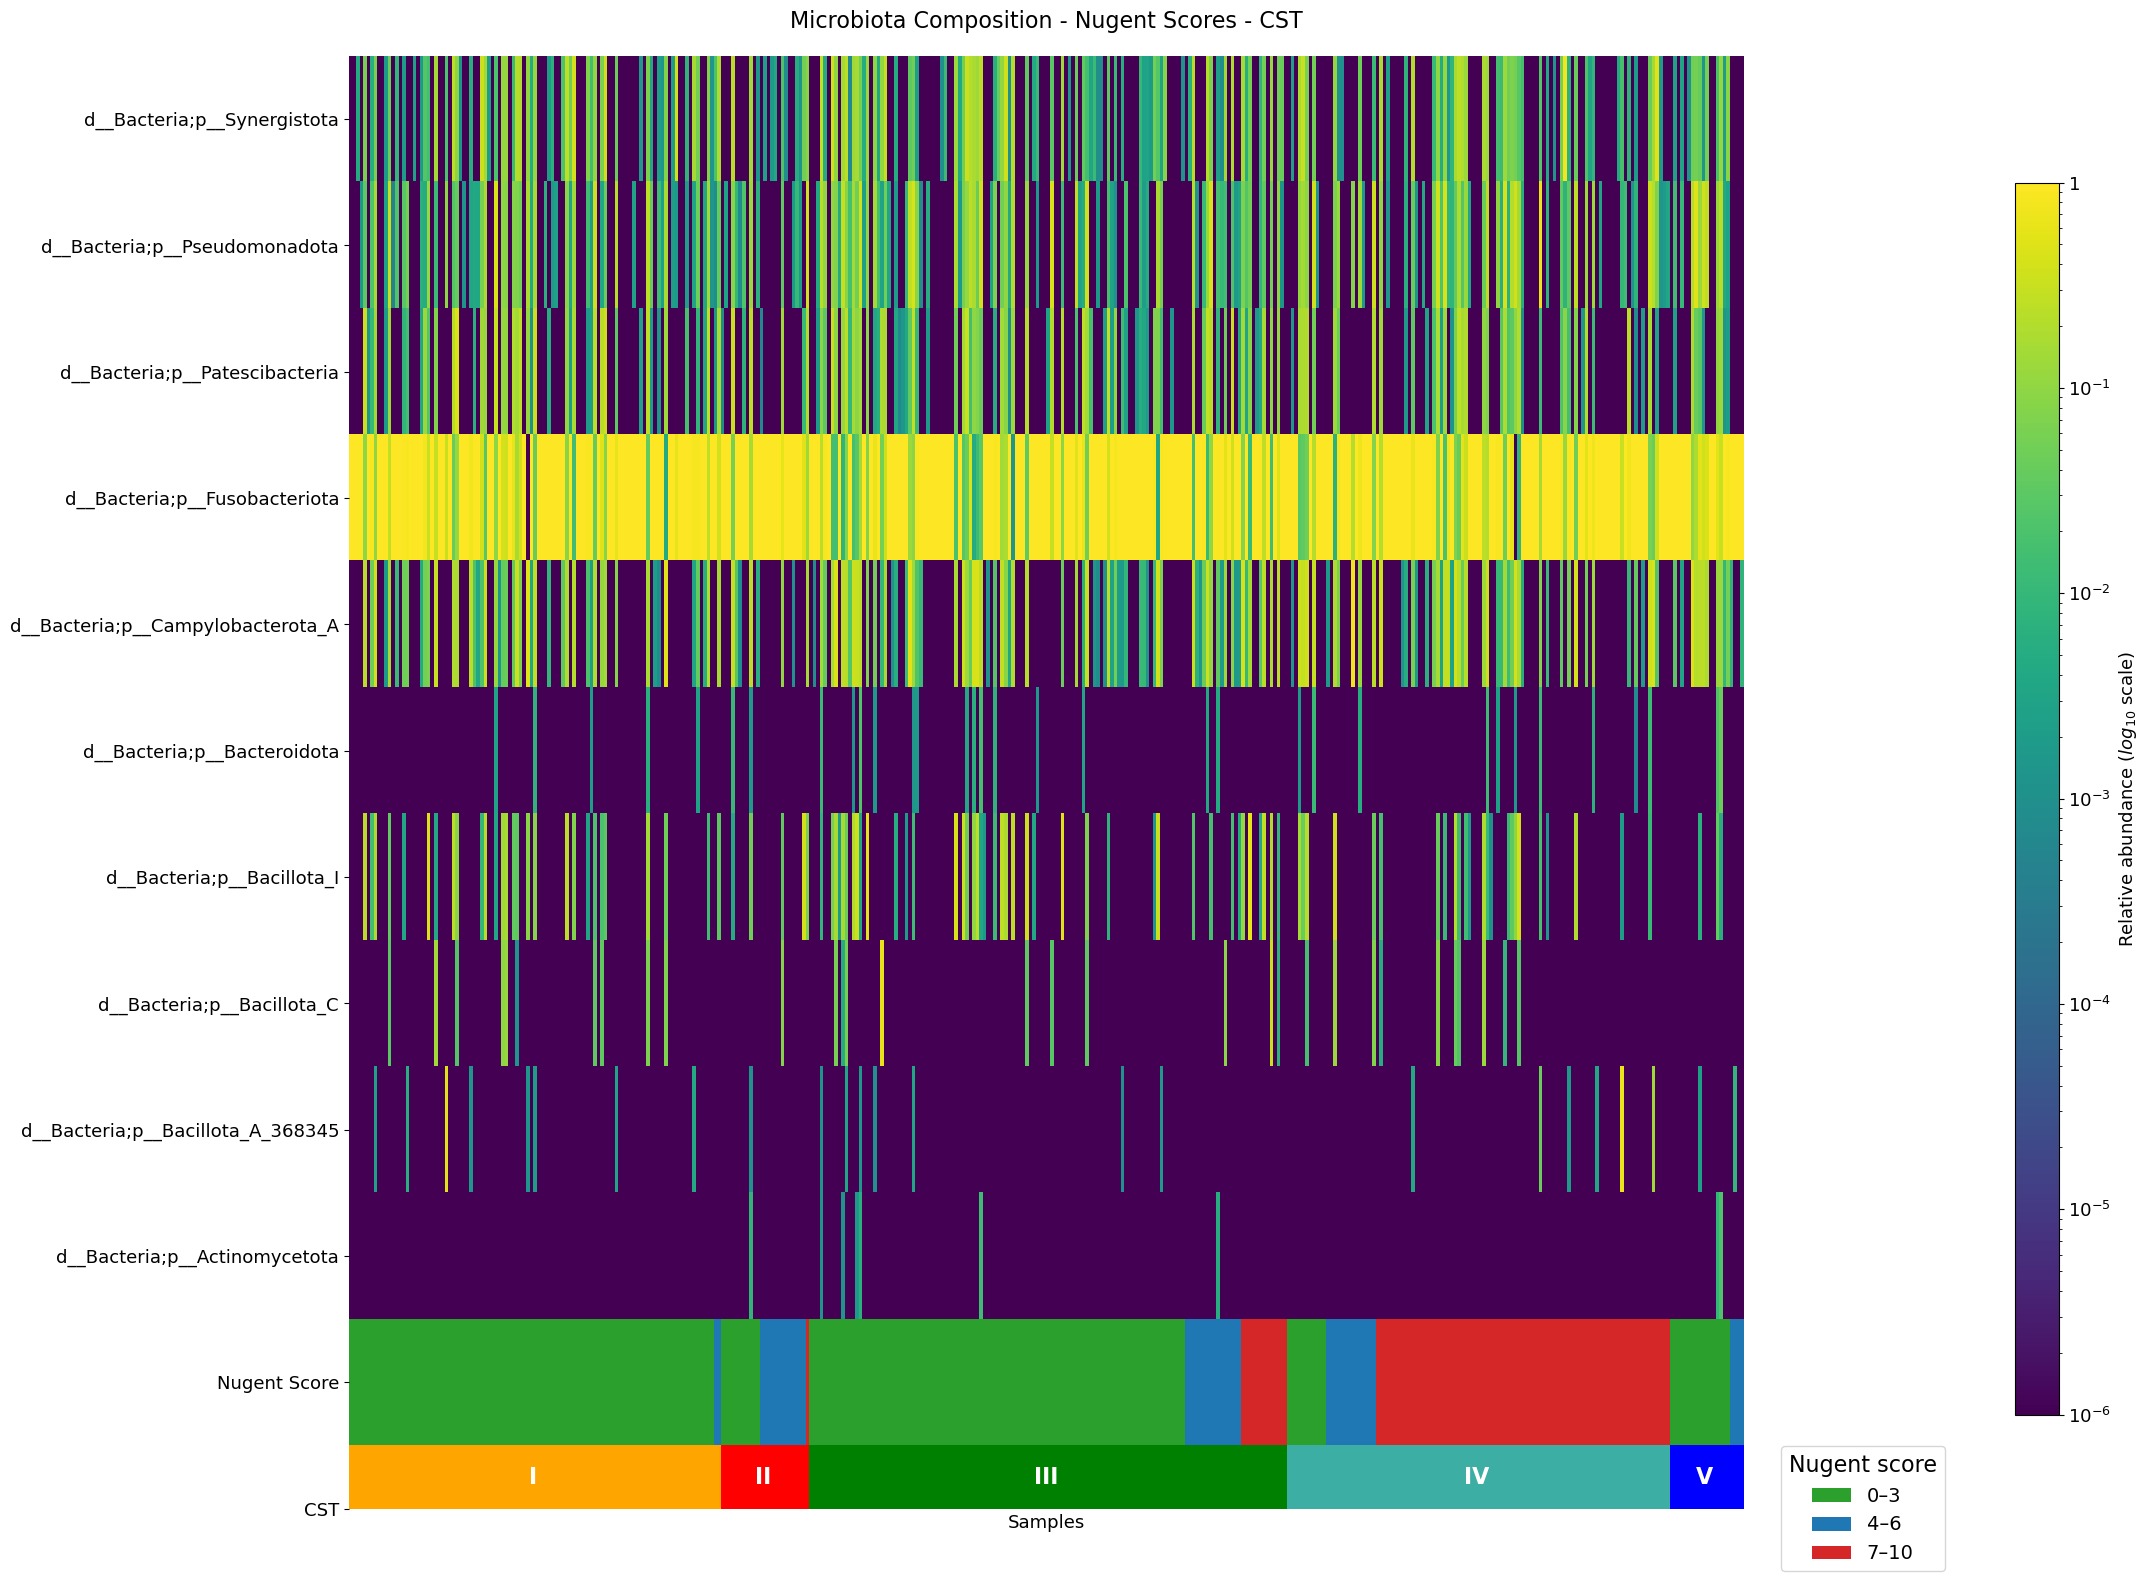

In [45]:
plot_species_with_cst_nugent_log(
    X_freq=X_freq,
    df=df,
    species_names=X_freq.columns.tolist()
)

# Figure S3

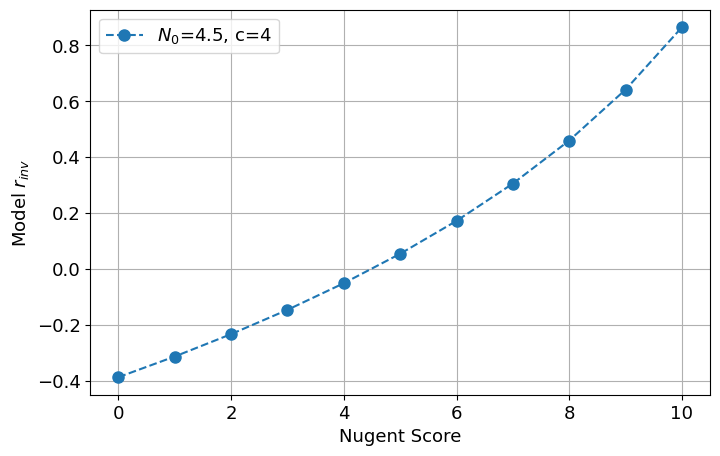

In [49]:
def transform_y(y, N0=None, c=None):
    if N0 is None or c is None:
        return y
    N_max = 10
    d = N_max - 2 * N0 + c
    transformed = np.log(N0 + d) - np.log(N_max - y + c)
    return transformed

# Input range
y_values = np.arange(0, 11)

# Parameters
N0 = 4.5
c=4
N_max = 10

# Compute transformed values
transformed_values = transform_y(y_values, N0=N0, c=c)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(y_values, transformed_values, marker='o', linestyle='--',markersize = 8, label=f'$N_0$={N0}, c={c}')
plt.xlabel('Nugent Score')
plt.ylabel('Model $r_{inv}$')
plt.grid(True)
plt.legend()
#plt.savefig("transformation.pdf",  bbox_inches='tight')
plt.show()